<table width="100%" style="border: none; border-collapse: collapse;">
  <tr>
    <td align="center" width="55%" style="border: none;">
      <h2>Centro de Investigación en Matemáticas, A.C.</h2>
    </td>
  </tr>
</table>

<h3 align="center">Estrategia 1, para la asignación de la categoría 'Sin etiqueta'</h3>

<h4 align="center">Autor: Sarahi Ventura Angoa</h4>

<p align="center">Maestría en Cómputo Estadístico - CIMAT Mty</p>
<p align="center">Junio 2025</p>


<div class="alert alert-block alert-info">
<strong>Evaluación de estrategias para la asignación de la categoría "Sin etiqueta"</strong><br><br>

Como se mencionó anteriormente, el modelo fue entrenado únicamente con las clases de interés. Sin embargo, al tratarse de imágenes urbanas, existen superpíxeles que contienen objetos o estructuras que <b>no pertenecen a ninguna de las clases entrenadas</b>, como automóviles, tinacos, postes, entre otros. Además, durante el proceso de segmentación, es común que se generen superpíxeles que mezclan coberturas distintas (por ejemplo, <i>techo de lámina</i> con <i>árbol</i>, o <i>hierba y pasto verde</i> con <i>suelo desnudo</i>), entre otras combinaciones. 

<br>
Por esta razón, surge la necesidad de diseñar una <b>estrategia para asignar la categoría "Sin etiqueta"</b> (clase <code>10</code>) a estos superpíxeles ambiguos.

<br>
En este <code>notebook</code> se evaluarán diferentes umbrales para <b>determinar cuál proporciona la mejor precisión promedio</b>. Para esta prueba, se seleccionaron imágenes que fueron <b>etiquetadas manualmente al 100%</b>, incluyendo la categoría "Sin etiqueta". Cabe destacar que, lógicamente, estas imágenes no fueron utilizadas durante el entrenamiento del modelo.

<br>
Estas mismas imágenes también fueron clasificadas automáticamente por el modelo previamente entrenado. Además de obtener la <code>prediction</code> de cada superpíxel, se extrajeron las <b>probabilidades por clase</b> las cuales estan ordenadas de mayor a menor, y algunas diferencias de probabilidades:

<ul>
    <li><code>1_proba_max</code>: probabilidad más alta.</li>
    <li><code>2_proba_max</code>: segunda probabilidad más alta.</li>
    <li><code>3_proba_max</code>, ..., hasta la probabilidad mínima.</li>
  </ul>

  
Por qué se guardan estas probabilidades ordenadas? Porque, al segmentar la imagen, se generan superpíxeles que a veces contienen una mezcla de coberturas (por ejemplo, <i>techo de lámina</i> con <i>árbol</i>, o <i>hierba y pasto verde</i> con <i>suelo desnudo</i>).<br><br>


Además de las columnas anteriores, como se menciona tambien se añadieron al <code>DataFrame</code> las siguientes columnas de diferencias entre probabilidades: 
<ul>
    <li><code>dif_1ra_2da_prob</code>: diferencia entre la probabilidad más alta y la segunda más alta.</li>
    <li><code>dif_1ra_3ra_prob</code>: diferencia entre la probabilidad más alta menos y la tercera más alta.</li>
</ul>

Esta información permitira implementar diferentes estrategias para asignar la categoría "Sin etiqueta" donde precisamente estan estos casos ambiguos o desconocidos, pues nos permiten analizar el <b>nivel de confianza</b> del modelo en cada predicción. Las predicciones automáticas fueron generadas en el notebook <code>clasificacion_automatica_img_prueba.ipynb</code>.

<br>
Con esta información, se implementaron distintas estrategias para <b>determinar el umbral óptimo</b>, comparando la certeza del modelo al asignar una categoría con las <b>etiquetas manuales</b>. Más adelante, se detallan las estrategias empleadas, el análisis exploratorio realizado para definir los umbrales y la justificación del umbral elegido.
</div>


<div class="alert alert-block alert-success">
<b>Importacion de las librerias</b></div>


In [23]:
import os
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

<div class="alert alert-block alert-success">
  <b>📁 Rutas de los archivos .csv utilizados en la evaluación</b><br><br>
  • <code>Caract_paralelo_{nombre_imagen}.csv</code>: Contiene la predicción por superpíxel realizada por el modelo previamente entrenado.<br>
  • <code>Etiquetado_{nombre_imagen}.csv</code>: Contiene la etiqueta asignada manualmente a cada superpíxel (etiquetado de referencia o "ground truth").
</div>



In [24]:
# Rutas

# Carpeta donde están las img de prueba y los archivos Etiquetado_ .csv y el .tif
ruta_carpeta_imagenes = "/home/victor/Documents/prueba_modelos/etiquetadas_prueba"  # Carpeta donde están las img de prueba y los archivos Etiquetado_ .csv y el .tif

# Carpeta donde están los archivos Caract_paralelo y los .tif  
ruta_salida_csv = "/home/victor/Documents/prediccion_img_prueba_mlp"  # Carpeta donde se guardaran los .csv predichos por el modelo y los .tif Caract_paralelo_


In [26]:
# --------------------------------------------
#  Diccionario de categorías con sus nombres
# --------------------------------------------
categorias = {
    0:  "Árbol",
    1:  "Suelo desnudo",
    2:  "Pavimento",
    3:  "Cuerpo de agua",
    4:  "Techo de lámina",
    5:  "Techo de losa",
    6:  "Arbusto",
    7:  "Hierba y pasto seco",
    8:  "Hierba y pasto verde",
    9:  "Sombra",
    10: "Sin etiqueta"   # Se asigna cuando el modelo está incierto
}

In [27]:
# ============================================
# UNIR TODAS LAS IMÁGENES EN UN SOLO DATAFRAME
# ============================================

# Obtener todos los archivos Caract_paralelo
archivos_caract = [f for f in os.listdir(ruta_salida_csv) if f.startswith("Caract_paralelo") and f.endswith(".csv")]

import pandas as pd
import os

# Lista donde vamos a guardar los datos de TODAS las imágenes
datos_todas_imagenes = []

for archivo_caract in archivos_caract:
    # -----------------------------------------
    # Obtener nombre base de la imagen
    # -----------------------------------------
    nombre_imagen = archivo_caract.replace("Caract_paralelo_", "").replace(".csv", "")
    archivo_etiquetado_manualmente = f"Etiquetado_{nombre_imagen}.csv"
    ruta_completa_etiquetado = os.path.join(ruta_carpeta_imagenes, archivo_etiquetado_manualmente)

    # -----------------------------------------
    # Verificar que existe el archivo de etiquetado manual
    # -----------------------------------------
    if not os.path.exists(ruta_completa_etiquetado):
        print(f"  Archivo no encontrado: {archivo_etiquetado_manualmente}. Saltando...")
        continue

    # -----------------------------------------
    # Columnas de interes del archivo de Caract_paralelo
    # -----------------------------------------
    df_caract = pd.read_csv(
        os.path.join(ruta_salida_csv, archivo_caract),
        usecols=["indice", "prediction", "1_proba_max", "2_proba_max",
                "3_proba_max", "4_proba_max", "5_proba_max", "6_proba_max",
                "7_proba_max", "8_proba_max", "9_proba_max", "10_proba_max","dif_1ra_2da_prob", "dif_1ra_3ra_prob"]
    )

    # -----------------------------------------
    # Columnas de interes del archivo de Etiquetado_
    # -----------------------------------------
    df_etiquetado = pd.read_csv(
        ruta_completa_etiquetado,
        usecols=["indice", "categoria"]
    )

    # -----------------------------------------
    # Unir por indice
    # -----------------------------------------
    df_comparacion = df_etiquetado.merge(
        df_caract,
        on="indice",
        how="left"
    )

    # -----------------------------------------
    # Agregar columna de nombre de imagen
    # -----------------------------------------
    df_comparacion["imagen"] = nombre_imagen

    # -----------------------------------------
    # Guardar en la lista general
    # -----------------------------------------
    datos_todas_imagenes.append(df_comparacion[["imagen", "indice", "categoria",     
                                                "prediction", "1_proba_max", "2_proba_max",
                                                "3_proba_max", "4_proba_max", "5_proba_max", "6_proba_max",
                                                "7_proba_max", "8_proba_max", "9_proba_max", "10_proba_max",
                                                "dif_1ra_2da_prob", "dif_1ra_3ra_prob"]])

# ============================================
# Concatenar TODAS las imágenes en UN SOLO DataFrame
# ============================================
df_completo_etiquetado_predicciones_original = pd.concat(datos_todas_imagenes, ignore_index=True)

print("\n DataFrame UNIDO con la infromacion de todas las images")
print(df_completo_etiquetado_predicciones_original.head())
print(f"Total de superpíxeles en TODO el dataset: {len(df_completo_etiquetado_predicciones_original)}")



 DataFrame UNIDO con la infromacion de todas las images
         imagen  indice  categoria  prediction  1_proba_max  2_proba_max  \
0  image_x5_176   601.0        9.0           9     0.947502     0.051459   
1  image_x5_176   622.0        9.0           9     0.994363     0.002533   
2  image_x5_176   614.0        9.0           9     0.917015     0.073948   
3  image_x5_176   598.0        9.0           9     0.964366     0.024248   
4  image_x5_176   565.0        9.0           9     0.945336     0.049148   

   3_proba_max  4_proba_max  5_proba_max  6_proba_max   7_proba_max  \
0     0.000558     0.000334     0.000117     0.000030  8.649306e-07   
1     0.001574     0.001181     0.000203     0.000094  2.943407e-05   
2     0.006878     0.001438     0.000653     0.000039  1.234611e-05   
3     0.007432     0.003255     0.000493     0.000144  4.132255e-05   
4     0.004528     0.000522     0.000300     0.000155  1.015106e-05   

    8_proba_max   9_proba_max  10_proba_max  dif_1ra_2da_pr

<div class="alert alert-block alert-info">
<stong>Función para medir el desempeño por modelo para cada umbral, para cada clase y de forma global</strong><br>

<ul>
    <li>Aqui cada fila representa las instancias reales de una clase específica <i>clase verdadera </i> según el etiquetado manual </li>
    <li>cada columna indica cuántas veces el modelo predijo esa clase <i>prediction</i> </li>
</ul>
</div>

In [28]:
def calcular_metricas_clases_con_resumen(df,
                                         col_real="categoria",
                                         col_pred="pred_estrat_1",
                                         categorias=None,
                                         clase_sin_etiqueta=10,
                                         incluir_sin_etiqueta=False):
    metricas = []
    clases = sorted(set(df[col_real].unique()) | set(df[col_pred].unique()))
    total_soporte = len(df)

    TP_total, FP_total, FN_total = 0, 0, 0

    for clase in clases:
        # nombre de la clase
        nombre = categorias.get(clase, f"Clase_{clase}") if categorias else f"Clase_{clase}"

        # True positives: predicción correcta, tanto la clase real como la predicha son iguales
        TP = ((df[col_real] == clase) & (df[col_pred] == clase)).sum()
        # Falses positives (FP): el modelo predijo esta clase, pero en realidad era otra (errores a lo largo de la columna i)
        FP = ((df[col_real] != clase) & (df[col_pred] == clase)).sum()
        # Falses negatives (FN): la instancia era realmente de esta clase, pero el modelo predijo otra (errores a lo largo de la fila j)
        FN = ((df[col_real] == clase) & (df[col_pred] != clase)).sum()
        # True negatives (TN): todas las instancias que no eran ni reales ni predichas como esta clase
        TN = ((df[col_real] != clase) & (df[col_pred] != clase)).sum()

        # Soporte: número de veces que esta clase aparece como verdadera (frecuencia real)
        soporte = (df[col_real] == clase).sum()
        # Peso relativo de esta clase (w_i), basado en su proporción del total
        peso = soporte / total_soporte if total_soporte > 0 else 0

        # -------------------------------------------------------------------------------------
        # Calculo de las métricas Accuracy, Presicion, Recall y F1-score 
        # ------------------------------------------------------------------------------------ 
        accuracy = (TP + TN) / (TP + TN + FP + FN)
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

        TP_total += TP
        FP_total += FP
        FN_total += FN

        metricas.append({
            "Clase": nombre,
            "TP": TP,
            "FP": FP,
            "FN": FN,
            "Soporte": soporte,
            "Peso w_i": peso,
            "Accuracy": accuracy,
            "Precisión": precision,
            "Recall": recall,
            "F1-score": f1,
            "w_i * Precisión": peso * precision,
            "w_i * Recall": peso * recall,
            "w_i * F1": peso * f1
        })

    df_metricas = pd.DataFrame(metricas)

    # Filtrar clase "Sin etiqueta" si no se quiere incluir
    if not incluir_sin_etiqueta and categorias:
        nombre_sin = categorias.get(clase_sin_etiqueta, "Sin etiqueta")
        df_filtrado = df_metricas[df_metricas["Clase"] != nombre_sin]
    else:
        df_filtrado = df_metricas

    # -------------------------------------------------------------------------------------
    # Calcular  Weighted-average 
    # ------------------------------------------------------------------------------------


    weighted_precision = df_filtrado["w_i * Precisión"].sum()
    weighted_recall = df_filtrado["w_i * Recall"].sum()
    weighted_f1 = df_filtrado["w_i * F1"].sum()

    metricas_globales = {
        "Precision_weighted": weighted_precision,
        "Recall_weighted": weighted_recall,
        "F1_weighted": weighted_f1
    }

    return df_metricas, metricas_globales


<div class="alert alert-block alert-warning">

<b>🎯 Estrategia 1: Asignación de la categoría "Sin etiqueta" basada en la diferencia entre la probabilidad más alta y la segunda más alta/b><br><br>

En esta estrategia se utiliza la <b>diferencia entre la probabilidad más alta y la segunda más alta</b> (<code>dif_1ra_2da_prob</code>) como indicador del nivel de certeza del modelo. Si esta diferencia es **pequeña**, significa que el modelo está <b>indeciso entre dos clases</b>, por lo que se considera la predicción como poco confiable.<br><br>

Se implementa la siguiente regla de asignación:<br>
<blockquote>
  Si <code>dif_1ra_2da_prob &lt; umbral</code>, entonces se asigna la categoría <code>10</code> ("Sin etiqueta").
</blockquote>

Para determinar el rango adecuado de umbrales a evaluar, se realiza primero un <b>análisis exploratorio</b> sobre el histograma de frecuencias de estas diferencias. Con esta información, se establece un rango de umbrales a probar (por ejemplo: 0.01, 0.02, ..., 0.10).<br><br>

Posteriormente, se comparan las predicciones ajustadas con esta estrategia contra las etiquetas manuales, con el objetivo de <b>determinar cuál umbral proporciona la mejor precisión promedio</b>.

</div>

<div class="alert alert-block alert-success">
  <b>🔎 Análisis exploratorio para establecer el rango del umbral</b><br><br>
</div>


In [29]:
import pandas as pd
import os

# Lista para guardar todas las diferencias de la primera estrategia
todas_dif_1ra_2da = []

for archivo in archivos_caract:
    ruta_completa = os.path.join(ruta_salida_csv, archivo)
    
    try:
        # Cargar solo la columna de interés
        df = pd.read_csv(ruta_completa, usecols=["dif_1ra_2da_prob"])
        
        # Agregar todos los valores de la columna a la lista
        todas_dif_1ra_2da.extend(df["dif_1ra_2da_prob"].tolist())
    
    except Exception as e:
        print(f"Error con archivo {archivo}: {e}")


<div class="alert alert-block alert-success">
  <b>📊 Resumen estadístico</b><br><br>
  Se presenta un resumen numérico (mínimo, máximo, media, mediana, varianza, desviación estándar) para describir la dispersión y tendencia central de las diferencias de probabilidad.
</div>

In [30]:
print("\n--- Resumen estadístico ---")
print("dif_1ra_2da_prob")
print(f"  Mínimo  : {np.min(todas_dif_1ra_2da):.4f}")
print(f"  Máximo  : {np.max(todas_dif_1ra_2da):.4f}")
print(f"  Media   : {np.mean(todas_dif_1ra_2da):.4f}")
print(f"  Mediana : {np.median(todas_dif_1ra_2da):.4f}")
print(f"  Varianza: {np.var(todas_dif_1ra_2da):.4f}")
print(f"  Desv. estándar: {np.std(todas_dif_1ra_2da):.4f}")



--- Resumen estadístico ---
dif_1ra_2da_prob
  Mínimo  : 0.0001
  Máximo  : 1.0000
  Media   : 0.5596
  Mediana : 0.5789
  Varianza: 0.0977
  Desv. estándar: 0.3126


<div class="alert alert-block alert-success">
  <b>📈 Histogramas de frecuencia absolutas de las diferencia entre la probabilidad más alta y la segunda más alta.</b> <br>
  Este gráfico permiten visualizar en qué rangos se concentran los casos más ambiguos y establecer sobre que intervalo probar los umbrales.
  <ul>
    <li>En el eje X se muestran los intervalos (bins) de la variable todas_dif_1ra_2da. </li>
    <li> En el eje Y se muestra cuántos valores caen en cada intervalo (frecuencia absolua)</li>
  </ul>
</div>


[dif_1ra_2da_prob] Pico más alto del histograma entre 0.980 y 1.000


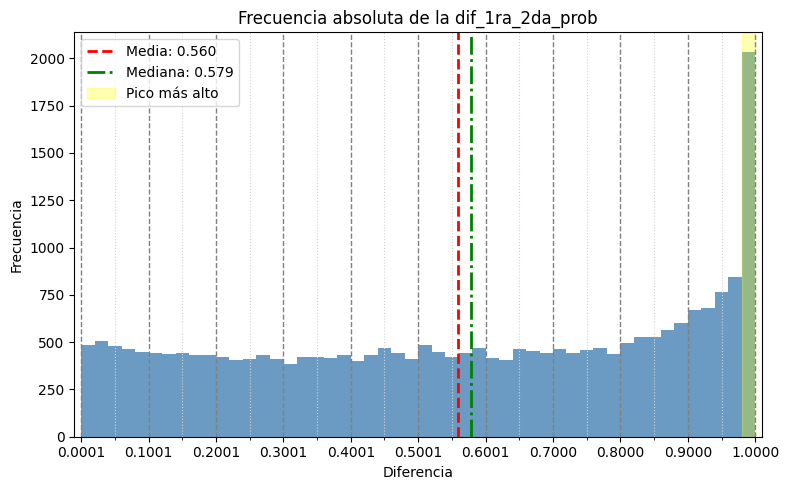

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------
# Calcular estadísticas
# ---------------------------------------

media_1ra_2da = np.mean(todas_dif_1ra_2da)
mediana_1ra_2da = np.median(todas_dif_1ra_2da)


# ---------------------------------------
# Calcular picos de histograma
# ---------------------------------------
counts_1, bin_edges_1 = np.histogram(todas_dif_1ra_2da, bins=50)
pico_inicio_1 = bin_edges_1[np.argmax(counts_1)]
pico_fin_1 = bin_edges_1[np.argmax(counts_1) + 1]

print(f"[dif_1ra_2da_prob] Pico más alto del histograma entre {pico_inicio_1:.3f} y {pico_fin_1:.3f}")

# ---------------------------------------
# Determinar rangos dinámicos de los ejes
# ---------------------------------------
minimo_1ra_2da = np.min(todas_dif_1ra_2da)
maximo_1ra_2da = np.max(todas_dif_1ra_2da)

# ---------------------------------------
# Crear figura y eje
# ---------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

# ---------------------------------------
# Histograma
# ---------------------------------------
ax.hist(todas_dif_1ra_2da, bins=50,color='steelblue', alpha=0.8)
ax.axvline(media_1ra_2da, color='red', linestyle='--', linewidth=2, label=f"Media: {media_1ra_2da:.3f}")
ax.axvline(mediana_1ra_2da, color='green', linestyle='-.', linewidth=2, label=f"Mediana: {mediana_1ra_2da:.3f}")
ax.axvspan(pico_inicio_1, pico_fin_1, color='yellow', alpha=0.3, label='Pico más alto')

ax.set_title("Frecuencia absoluta de la dif_1ra_2da_prob")
ax.set_xlabel("Diferencia")
ax.set_ylabel("Frecuencia")
ax.legend()

# Ajustar límites del eje X dinámicamente
ax.set_xlim(minimo_1ra_2da - 0.01, maximo_1ra_2da + 0.01)

# Ajustar ticks principales y secundarios dinámicos
ticks_major_1 = np.linspace(minimo_1ra_2da, maximo_1ra_2da, 11)
ticks_minor_1 = np.linspace(minimo_1ra_2da, maximo_1ra_2da, 21)
ax.set_xticks(ticks_major_1)
ax.set_xticks(ticks_minor_1, minor=True)

ax.grid(which='major', axis='x', color='gray', linestyle='--', linewidth=1.0)
ax.grid(which='minor', axis='x', color='lightgray', linestyle=':', linewidth=0.8)

plt.tight_layout()
plt.show()

<div class="alert alert-info">

<b>📊 Conclusiones del gráfico de frecuencias de <code>dif_1ra_2da_prob</code></b><br><br>

En esta gráfica, el eje <i>x</i> representa la diferencia entre la probabilidad más alta y la segunda más alta asignadas por el modelo a cada superpíxel.<br>
El eje <i>y</i> muestra la <b>frecuencia absoluta</b>, es decir, el <b>número de superpíxeles</b> cuyos valores de <code>dif_1ra_2da_prob</code> caen dentro de cada intervalo del histograma.<br><br>

Se observa que la distribución es casi plana, con un comportamiento similar a una distribución uniforme, ya que no presenta picos pronunciados ni zonas claras de concentración. Durante la mayor parte del rango, la frecuencia se mantiene aproximadamente constante (cerca de 500 superpíxeles por intervalo). Esto sugiere que la diferencia entre la probabilidad más alta y la segunda crece de forma gradual y continua, sin cambios bruscos, desde 0.0 hasta aproximadamente 0.82.<br><br>

A partir de 0.82, se aprecia un aumento muy suave y progresivo en la frecuencia, llegando a alrededor de 750 superpíxeles cerca de 0.98. Sin embargo, después de este punto ocurre un salto abrupto: entre 0.980 y 1.0 (zona sombreada en amarillo) aparece un pico cercano a 1900 superpíxeles, lo que evidencia un conjunto importante de casos donde la primera probabilidad supera ampliamente a la segunda (predicciones muy seguras).<br><br>

En el gráfico también se indican la <b>media</b> (0.560, línea roja punteada) y la <b>mediana</b> (0.597, línea verde punteada). Esto significa que el 50% de los superpíxeles tiene un valor de <code>dif_1ra_2da_prob</code> mayor o igual a 0.597 y el otro 50% menor.  
La <b>desviación estándar</b> (0.3126) indica que existe una variabilidad considerable en el nivel de certeza del modelo al distinguir entre las dos clases más probables.<br><br>

Es importante destacar que, aunque una diferencia grande entre la primera y segunda probabilidad implica mayor confianza, el resto de la probabilidad no se reparte de manera uniforme entre las otras clases. La forma en que se distribuye depende del comportamiento del modelo y de los patrones aprendidos; en algunos casos puede repartirse de forma homogénea, pero en otros puede concentrarse en ciertas clases específicas. Por ello, la magnitud de <code>dif_1ra_2da_prob</code> es un indicador directo y útil de la incertidumbre en la predicción.<br><br>

<hr>

<b>🎯 Ajuste del rango de umbrales</b><br><br>

Tras analizar la distribución de <code>dif_1ra_2da_prob</code>, se definió el siguiente rango de umbrales a evaluar:<br><br>

<blockquote>
  <code>np.arange(0.0, 0.30, 0.01)</code>
</blockquote>

Esto significa:<br>

<ul>
  <li><b>start = 0.0</b>: el rango comienza en 0.0 (incluido).</li>
  <li><b>stop = 0.30</b>: se detiene antes de 0.30.</li>
  <li><b>step = 0.01</b>: los valores aumentan en incrementos de 0.01.</li>
</ul>

De este modo, se evaluará con mayor detalle el desempeño del modelo bajo distintos umbrales, buscando <b>maximizar la precisión general</b> mientras se mantiene <b>un porcentaje razonable de asignaciones a "Sin etiqueta" (clase 10)</b>.

</div>


In [32]:
umbrales_estrategia_1 = np.arange(0.0, 0.30, 0.01)  
resultados_umbral_estrategia_1 = []

In [33]:
lista_porcentaje_sin_etiqueta_umbral = []
lista_metricas_globales = []

lista_metricas_todos_los_umbral = []

for umbral in umbrales_estrategia_1:
    print(f"\n=======================")
    print(f" Evaluando UMBRAL: {umbral:.3f}")
    print("=======================\n")
    # -----------------------------------------
    # Aplicar el umbral para todas las filas
    # -----------------------------------------

    # Copiamos el DataFrame original para no modificarlo
    df_umbral = df_completo_etiquetado_predicciones_original.copy()

    # Inicializamos la columna de predicción filtrada por estrategia 1
    df_umbral["pred_estrat_1"] = df_umbral["prediction"]
    
    # Si la diferencia de probabilidad es menor al umbral, asignamos "Sin etiqueta" (10)
    df_umbral.loc[df_umbral["dif_1ra_2da_prob"] < umbral, "pred_estrat_1"] = 10

    # ----------------------------------------------------
    # Contar cuántos superpíxeles quedan "Sin etiqueta"
    # ----------------------------------------------------

    total_superpixeles_global = len(df_umbral) 
    total_sin_etiqueta  = (df_umbral["pred_estrat_1"] == 10).sum()
    porcentaje_sin_etiqueta = 100 * total_sin_etiqueta / total_superpixeles_global

    # -------------------------------------------------------------------------------------------
    # llamada de la funcion para el calculo de las metricas por clase y globales para cada Umbral
    #-----------------------------------------------------------------------------------------
    df_clase, metricas_globales = calcular_metricas_clases_con_resumen(
        df_umbral,
        col_real="categoria",
        col_pred="pred_estrat_1",
        categorias=categorias,
        clase_sin_etiqueta=10,
        incluir_sin_etiqueta=True  # O False para NO incluir la categoria sin etiqueta, o True para SI incluir la categoría sin etiqueta
    )

    # Redondear los valores de la impresion
    num_decimales = 6
    metricas_clase = df_clase[[
        "Clase", "TP", "FP", "FN", "Soporte", "Peso w_i", "Accuracy", "Precisión", "Recall", "F1-score",
        "w_i * Precisión", "w_i * Recall", "w_i * F1"
    ]].copy()
    # Agregar el umbral como columna
    metricas_clase["Umbral"] = umbral   
    metricas_clase = metricas_clase.round(num_decimales)
    print(metricas_clase.to_string(index=False))  # Impresión estilo tabla

    lista_metricas_todos_los_umbral.append(metricas_clase.copy())

    # Guardar el porcentaje de sin etiqueta para cada umbral
    lista_porcentaje_sin_etiqueta_umbral.append({
        "Umbral": umbral,
        "Porcentaje_SinEtiqueta": porcentaje_sin_etiqueta})

    # Globales
    print(f"Precision_weighted: {metricas_globales['Precision_weighted']:.3f}")
    print(f"Recall_weighted: {metricas_globales['Recall_weighted']:.3f}")
    print(f"F1_weighted: {metricas_globales['F1_weighted']:.3f}")

    fila_global = {
    "Umbral": umbral,
    "Porcentaje_SinEtiqueta": porcentaje_sin_etiqueta,
    **metricas_globales
    }
    lista_metricas_globales.append(fila_global)

df_porcentajes_sin_etiqueta = pd.DataFrame(lista_porcentaje_sin_etiqueta_umbral)
df_metricas_globales_umbral = pd.DataFrame(lista_metricas_globales)

df_metricas_todos_los_umbral = pd.concat(lista_metricas_todos_los_umbral, ignore_index=True)



 Evaluando UMBRAL: 0.000

               Clase   TP   FP   FN  Soporte  Peso w_i  Accuracy  Precisión   Recall  F1-score  w_i * Precisión  w_i * Recall  w_i * F1  Umbral
               Árbol 1954 3562  387     2341  0.093539  0.842210   0.354242 0.834686  0.497391         0.033135      0.078076  0.046525     0.0
       Suelo desnudo 2087 1708  724     2811  0.112319  0.902825   0.549934 0.742440  0.631850         0.061768      0.083390  0.070969     0.0
           Pavimento 1367  974  458     1825  0.072921  0.942782   0.583938 0.749041  0.656265         0.042582      0.054621  0.047856     0.0
      Cuerpo de agua  395   12  234      629  0.025133  0.990171   0.970516 0.627981  0.762548         0.024392      0.015783  0.019165     0.0
     Techo de lámina 3529 1176  185     3714  0.148400  0.945619   0.750053 0.950188  0.838342         0.111308      0.141008  0.124410     0.0
       Techo de losa  948  693  788     1736  0.069365  0.940824   0.577697 0.546083  0.561445         0.0400

In [35]:
lista_metricas_globales

[{'Umbral': np.float64(0.0),
  'Porcentaje_SinEtiqueta': np.float64(0.0),
  'Precision_weighted': np.float64(0.4208571801098464),
  'Recall_weighted': np.float64(0.5368202341471211),
  'F1_weighted': np.float64(0.4560171308999285)},
 {'Umbral': np.float64(0.01),
  'Porcentaje_SinEtiqueta': np.float64(0.9749470571782475),
  'Precision_weighted': np.float64(0.4918082122851675),
  'Recall_weighted': np.float64(0.5372198026131777),
  'F1_weighted': np.float64(0.4613198809747712)},
 {'Umbral': np.float64(0.02),
  'Porcentaje_SinEtiqueta': np.float64(1.8939545291085627),
  'Precision_weighted': np.float64(0.49564847538893175),
  'Recall_weighted': np.float64(0.5375794142326288),
  'F1_weighted': np.float64(0.46594781603441626)},
 {'Umbral': np.float64(0.03),
  'Porcentaje_SinEtiqueta': np.float64(2.9048627482319094),
  'Precision_weighted': np.float64(0.4972858771207171),
  'Recall_weighted': np.float64(0.5375394573860232),
  'F1_weighted': np.float64(0.4704528055384883)},
 {'Umbral': np.flo

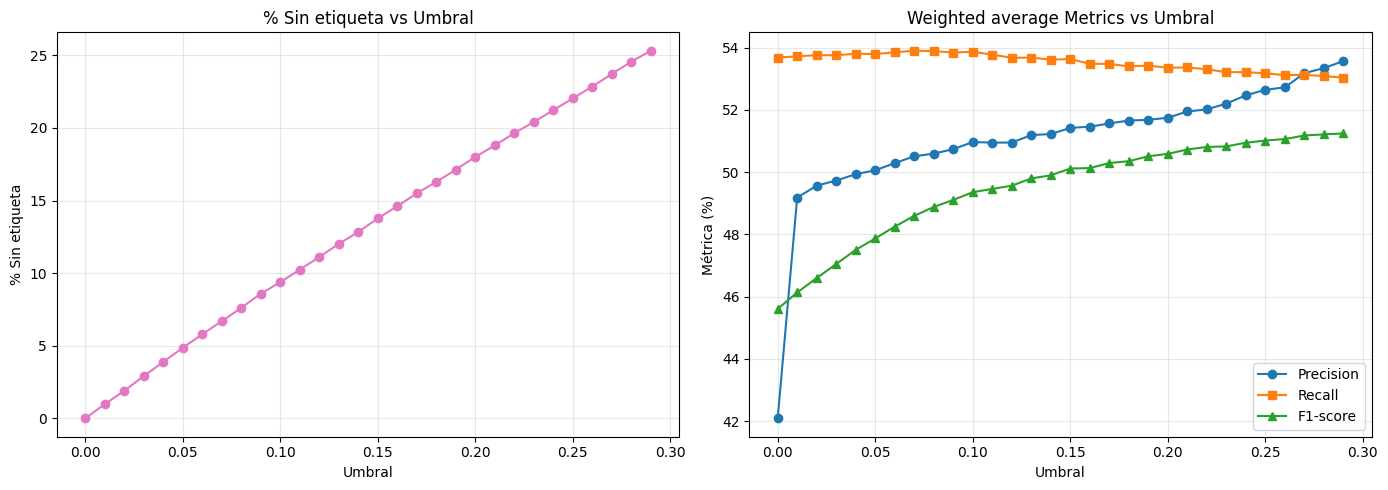

In [12]:
import matplotlib.pyplot as plt

# Crear figura con dos subgráficos en una fila
fig, axes = plt.subplots(ncols=2, figsize=(14, 5)) 

# --------------------------------------------
# GRÁFICO 1: Umbral vs % Sin etiqueta
# --------------------------------------------
axes[0].plot(
    df_porcentajes_sin_etiqueta["Umbral"],
    df_porcentajes_sin_etiqueta["Porcentaje_SinEtiqueta"],
    marker='o',
    color='tab:pink'
)
axes[0].set_title("% Sin etiqueta vs Umbral")
axes[0].set_xlabel("Umbral")
axes[0].set_ylabel("% Sin etiqueta")
axes[0].grid(alpha=0.3)

# --------------------------------------------
# GRÁFICO 2: Umbral vs métricas macro
# --------------------------------------------
axes[1].plot(
    df_metricas_globales_umbral["Umbral"],
    100 * df_metricas_globales_umbral["Precision_weighted"],
    label="Precision", marker='o'
)
axes[1].plot(
    df_metricas_globales_umbral["Umbral"],
    100 * df_metricas_globales_umbral["Recall_weighted"],
    label="Recall", marker='s'
)
axes[1].plot(
    df_metricas_globales_umbral["Umbral"],
    100 * df_metricas_globales_umbral["F1_weighted"],
    label="F1-score", marker='^'
)

axes[1].set_title("Weighted average Metrics vs Umbral")
axes[1].set_xlabel("Umbral")
axes[1].set_ylabel("Métrica (%)")
axes[1].legend()
axes[1].grid(alpha=0.3)

# Ajustar espacios
plt.tight_layout()
plt.show()


<div class="alert alert-info">
<h4>📈 Gráfica de la izquierda</h4>

<ul>
  <li>
    <b> Eje x: </b> Umbral que se usa para decidir si una predicción es suficientemente segura.
  </li>
  <li>
    <b> Eje y:</b> Porcentaje de superpíxeles/instancias que quedan "Sin etiqueta" (porque su confianza es menor al umbral)
  </li>
</ul>

<br>
<h4>📈 Gráfica de la derecha</h4>

<ul>
  <li>
    <b> Eje x: </b> Umbral que se usa para decidir si una predicción es suficientemente segura.
  </li>
  <li>
    <b> Eje y:</b> Métricas Weighted-average en porcentaje (%)
  </li>
</ul>


<p><b> Conclusión:</b> El objetivo es lograr un equilibrio: elegir un umbral que descarte predicciones altamente inciertas (mejorando la precisión), pero sin elevar excesivamente el porcentaje de "Sin etiqueta". Con base en la gráfica, se ha elegido un <b>umbral de 0.10</b> por mantener un buen balance entre <i>precisión general</i> y un <i>porcentaje razonable de asignaciones a "Sin etiqueta"</i>.</p>
</div>


<div class="alert alert-info">

<h4>📊 Interpretación de las métricas y selección del umbral</h4>

Las métricas calculadas usando promedio <b>weighted</b> permiten evaluar el desempeño global del modelo en un escenario multiclase con desbalance, ya que ponderan la contribución de cada clase según su frecuencia. Estas métricas ofrecen una visión más realista del rendimiento general del clasificador.

<ul>
  <li><b>Precisión (Precision):</b> indica qué tan confiables son las etiquetas asignadas por el modelo.</li>
  <li><b>Recall (Exhaustividad):</b> mide cuántos elementos verdaderos fueron correctamente identificados.</li>
  <li><b>F1-score:</b> refleja un equilibrio entre precisión y recall.</li>
</ul>

<ul>

  <li>
    El <b>Recall Weighted</b> se mantiene casi constante entre 0.536 y 0.539 para umbrales entre 0 y 0.10. A partir de ahí comienza un descenso suave y continuo.
    <br>
    Este comportamiento ocurre porque, al elevar el umbral, el modelo deja de asignar una clase cuando la diferencia entre la primera y segunda probabilidad es pequeña, asignando más superpixeles a la categoría <i>“Sin etiqueta”</i>. 
    <br>
    Como consecuencia, algunas instancias que antes eran predichas correctamente (TP) se convierten en falsos negativos (FN), lo que reduce ligeramente la capacidad del modelo para “recuperar” los ejemplos reales.
    <br>
    El recall ponderado alcanza su valor más alto en el umbral 0.07 (0.5390) y el más bajo en 0.29 (0.5303).
    <br>
  </li>

  <li>
    La <b>Precisión Weighted</b> muestra una mejora clara a medida que crece el umbral. 
    <br>
    Sin aplicar umbral, la precisión es 0.4208. Al aplicar un umbral mínimo de 0.01, sube abruptamente a 0.4918; a partir de ahí aumenta casi de forma monótona. Esto se debe a que las predicciones que permanecen (las que no se mandan a <i>“Sin etiqueta”</i>) son aquellas en el que el modelo no tiene ambiguedad sobre a que clase pertenece el superpixel.
    <br>
    En otras palabras, el modelo comete menos errores porque solo etiqueta cuando la diferencia entre probabilidades es suficientemente alta. La precisión máxima observada es 0.5337 al umbral 0.29.
    <br>
  </li>

  <li>
    El <b>F1-score Weighted</b>, que combina precisión y recall en un solo valor, muestra un crecimiento continuo con el aumento del umbral. Este comportamiento es coherente: la precisión aumenta de forma clara y el recall apenas disminuye. 
    <br><br>
    Por lo tanto, el balance general del modelo mejora cuando se exige una separación mayor entre las dos clases más probables. El F1 weighted crece de 0.4560 (sin umbral) hasta 0.5124 en el umbral 0.29.
  </li>

</ul>

<hr>

<h5>🟨 Impacto del umbral y la clase <code>“Sin etiqueta”</code></h5>

<p>
Conforme el <b>umbral aumenta</b>, más superpíxeles son asignados a la categoría <code>“Sin etiqueta”</code>, ya que la diferencia entre la primera y la segunda probabilidad no supera el valor exigido. Esto conduce a predicciones más conservadoras: el modelo solo clasifica cuando está realmente seguro. 
<br><br>
El efecto directo es una mejora en la precisión, una pequeña disminución en el recall y un aumento global en el F1 ponderado, lo que indica un mejor balance entre ambos componentes.
</p>

</div>



<div style="background-color:#fff3cd; padding: 12px; border-left: 5px solid #ffc107; font-size: 15px;">
  <strong>Recomendación:</strong> Un umbral <strong>0.10 </strong> pues ofrece el mejor balance entre precisión, recall y f1-score y cobertura. 
</div>



<div class="alert alert-block alert-success">
  <strong>📊 Grafica de desempeño por clase frente a distintos umbrales de asignación de la clase 'Sin etiqueta'</strong><br>
</div>

In [13]:
# Pivotar el DataFrame para tener umbrales como índice y clases como columnas
df_accu_prec_recall_f1_pivot = df_metricas_todos_los_umbral.pivot(
    index="Umbral", columns="Clase", values=["Accuracy", "Precisión", "Recall", "F1-score"]
)

categorias = [
    'Árbol',
    'Suelo desnudo',
    'Pavimento',
    'Cuerpo de agua',
    'Techo de lámina',
    'Techo de losa',
    'Arbusto',
    'Hierba y pasto seco',
    'Hierba y pasto verde',
    'Sombra',
    'Sin etiqueta'
]

# Diccionario de colores
color_dict = {
    'Árbol': (0,139,69), 
    'Suelo desnudo': (255, 153, 18), 
    'Pavimento': (104, 131, 139), 
    'Cuerpo de agua': (61, 85, 171), 
    'Techo de lámina': (205, 104, 137), 
    'Techo de losa': (128,0,0),
    'Arbusto': (47, 107, 85),
    'Hierba y pasto seco': (255, 255, 0),
    'Hierba y pasto verde': (0, 252, 124),
    'Sombra': (105, 105, 105),
    'Sin etiqueta': (0, 0, 0)
}

# Colores normalizados en el orden correcto
colores_rgb_norm = [np.array(color_dict[cat]) / 255.0 for cat in categorias]


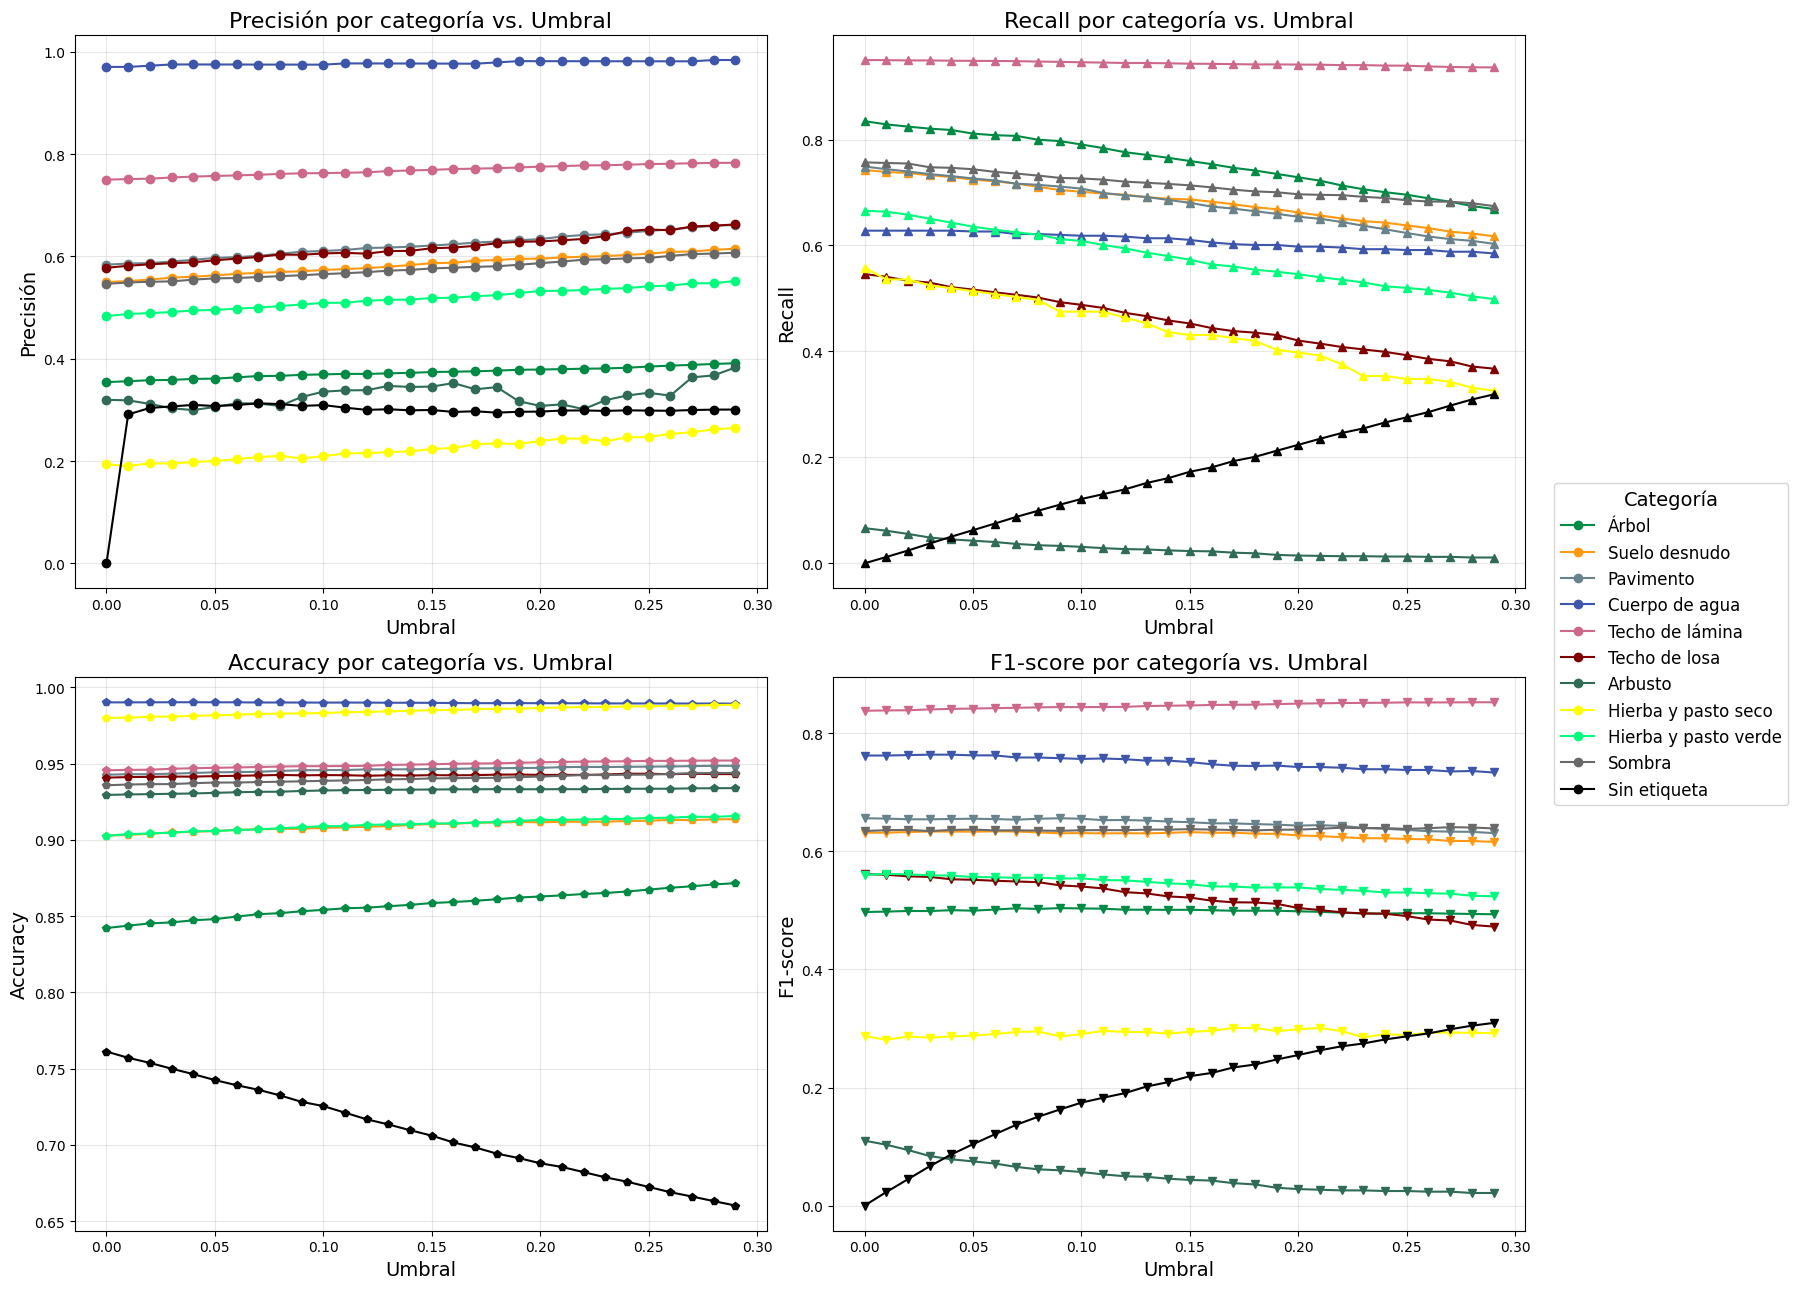

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Crear figura
fig, axes = plt.subplots(ncols=2, nrows=2, figsize=(18, 13))

# -------------------------------------------------------
# Gráfico 1: Precisión por categoría vs Umbral
# -------------------------------------------------------
for i, clase in enumerate(categorias):
    if clase in df_accu_prec_recall_f1_pivot["Precisión"].columns:
        axes[0,0].plot(
            df_accu_prec_recall_f1_pivot.index,
            df_accu_prec_recall_f1_pivot["Precisión"][clase],
            label=clase,
            color=colores_rgb_norm[i],
            marker='o'
        )

axes[0,0].set_title("Precisión por categoría vs. Umbral", fontsize=16)
axes[0,0].set_xlabel("Umbral", fontsize=14)
axes[0,0].set_ylabel("Precisión", fontsize=14)
axes[0,0].grid(alpha=0.3)

# -------------------------------------------------------
# Gráfico 2: Recall por categoría vs Umbral
# -------------------------------------------------------
for i, clase in enumerate(categorias):
    if clase in df_accu_prec_recall_f1_pivot["Recall"].columns:
        axes[0,1].plot(
            df_accu_prec_recall_f1_pivot.index,
            df_accu_prec_recall_f1_pivot["Recall"][clase],
            label=clase,
            color=colores_rgb_norm[i],
            marker='^'
        )

axes[0,1].set_title("Recall por categoría vs. Umbral", fontsize=16)
axes[0,1].set_xlabel("Umbral", fontsize=14)
axes[0,1].set_ylabel("Recall", fontsize=14)
axes[0,1].grid(alpha=0.3)


# -------------------------------------------------------
# Gráfico 3: Accuracy por categoría vs Umbral
# -------------------------------------------------------
for i, clase in enumerate(categorias):
    if clase in df_accu_prec_recall_f1_pivot["Accuracy"].columns:
        axes[1,0].plot(
            df_accu_prec_recall_f1_pivot.index,
            df_accu_prec_recall_f1_pivot["Accuracy"][clase],
            label=clase,
            color=colores_rgb_norm[i],
            marker='p'
        )

axes[1,0].set_title("Accuracy por categoría vs. Umbral", fontsize=16)
axes[1,0].set_xlabel("Umbral", fontsize=14)
axes[1,0].set_ylabel("Accuracy", fontsize=14)
axes[1,0].grid(alpha=0.3)

# -------------------------------------------------------
# Gráfico 4: F1  por categoría vs Umbral
# -------------------------------------------------------
for i, clase in enumerate(categorias):
    if clase in df_accu_prec_recall_f1_pivot["F1-score"].columns:
        axes[1,1].plot(
            df_accu_prec_recall_f1_pivot.index,
            df_accu_prec_recall_f1_pivot["F1-score"][clase],
            label=clase,
            color=colores_rgb_norm[i],
            marker='v'
        )

axes[1,1].set_title("F1-score por categoría vs. Umbral", fontsize=16)
axes[1,1].set_xlabel("Umbral", fontsize=14)
axes[1,1].set_ylabel("F1-score", fontsize=14)
axes[1,1].grid(alpha=0.3)

# -------------------------------------------------------
# Una sola leyenda general
# -------------------------------------------------------
fig.legend(
    categorias, 
    title="Categoría",
    title_fontsize=14,  # Aumenta el tamaño del título
    fontsize=12,        # Tamaño del texto de las categorías
    loc="center right"
)

plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()


<div class="alert alert-block alert-success">
  <strong>📊 Tabla del valor de la precisión por clase y umbral</strong><br>
</div>

In [47]:
# Paso 1: Crear la tabla resumen precision por clase y umbral
tabla_precision_por_umbral = df_metricas_todos_los_umbral.pivot(
    index="Umbral", columns="Clase", values="Precisión"
).reset_index()

print(tabla_precision_por_umbral.round(3))

Clase  Umbral  Arbusto  Cuerpo de agua  Hierba y pasto seco  \
0        0.00    0.320           0.971                0.193   
1        0.01    0.319           0.971                0.190   
2        0.02    0.312           0.973                0.196   
3        0.03    0.303           0.975                0.195   
4        0.04    0.300           0.975                0.198   
5        0.05    0.306           0.975                0.200   
6        0.06    0.313           0.975                0.204   
7        0.07    0.312           0.975                0.208   
8        0.08    0.308           0.975                0.210   
9        0.09    0.325           0.975                0.205   
10       0.10    0.336           0.975                0.209   
11       0.11    0.338           0.977                0.215   
12       0.12    0.338           0.977                0.215   
13       0.13    0.347           0.977                0.218   
14       0.14    0.345           0.977                0

<div class="alert alert-block alert-success">
  <strong>📊 Tabla del valor del recall por clase y umbral</strong><br>
</div>

In [48]:
tabla_recall_por_umbral = df_metricas_todos_los_umbral.pivot(
    index="Umbral", columns="Clase", values="Recall"
).reset_index()


print(tabla_recall_por_umbral.round(3))

Clase  Umbral  Arbusto  Cuerpo de agua  Hierba y pasto seco  \
0        0.00    0.066           0.628                0.558   
1        0.01    0.062           0.628                0.536   
2        0.02    0.055           0.628                0.536   
3        0.03    0.049           0.628                0.525   
4        0.04    0.045           0.628                0.519   
5        0.05    0.043           0.626                0.514   
6        0.06    0.040           0.626                0.508   
7        0.07    0.037           0.622                0.503   
8        0.08    0.034           0.622                0.497   
9        0.09    0.033           0.620                0.475   
10       0.10    0.031           0.618                0.475   
11       0.11    0.029           0.618                0.475   
12       0.12    0.027           0.617                0.464   
13       0.13    0.026           0.614                0.453   
14       0.14    0.024           0.614                0

<div class="alert alert-block alert-success">
  <strong>📊 Tabla del valor del F1-score por clase y umbral</strong><br>
</div>

In [ ]:
# Paso 1: Crear la tabla resumen F1-score por clase y umbral
tabla_f1_por_umbral = df_metricas_todos_los_umbral.pivot(
    index="Umbral", columns="Clase", values="F1-score"
).reset_index()


print(tabla_f1_por_umbral.round(3))

Clase  Umbral  Arbusto  Cuerpo de agua  Hierba y pasto seco  \
0        0.00    0.110           0.763                0.287   
1        0.01    0.103           0.763                0.281   
2        0.02    0.094           0.763                0.287   
3        0.03    0.084           0.764                0.284   
4        0.04    0.078           0.764                0.287   
5        0.05    0.075           0.763                0.288   
6        0.06    0.071           0.763                0.291   
7        0.07    0.065           0.759                0.294   
8        0.08    0.061           0.759                0.295   
9        0.09    0.060           0.758                0.287   
10       0.10    0.057           0.757                0.291   
11       0.11    0.053           0.758                0.296   
12       0.12    0.050           0.756                0.294   
13       0.13    0.049           0.754                0.294   
14       0.14    0.046           0.754                0

In [16]:
tabla_f1_por_umbral

Clase,Umbral,Arbusto,Cuerpo de agua,Hierba y pasto seco,Hierba y pasto verde,Pavimento,Sin etiqueta,Sombra,Suelo desnudo,Techo de losa,Techo de lámina,Árbol
0,0.00,0.109934,0.762548,0.287340,0.560072,0.656265,0.000000,0.634668,0.631850,0.561445,0.838342,0.497391
1,0.01,0.103114,0.762548,0.280753,0.562080,0.655722,0.022830,0.636073,0.631787,0.560597,0.839001,0.498074
2,0.02,0.094105,0.763285,0.286558,0.561230,0.654545,0.044651,0.636613,0.632946,0.557831,0.839224,0.499159
3,0.03,0.083945,0.764023,0.284431,0.559764,0.654466,0.066537,0.634584,0.633733,0.556901,0.840725,0.499026
4,0.04,0.078348,0.764023,0.286585,0.559060,0.655045,0.086644,0.636448,0.633694,0.552841,0.841552,0.500523
5,0.05,0.074826,0.762827,0.287926,0.556705,0.655462,0.104004,0.637082,0.633479,0.552000,0.842219,0.499671
6,0.06,0.071236,0.762827,0.290679,0.556209,0.654916,0.120690,0.635706,0.634131,0.550356,0.842785,0.501524
7,0.07,0.065431,0.759223,0.294023,0.555344,0.653837,0.136976,0.635724,0.633747,0.549142,0.843454,0.503733
8,0.08,0.061404,0.759223,0.295082,0.555556,0.655441,0.150489,0.635422,0.632379,0.547971,0.844151,0.502618
9,0.09,0.059735,0.758017,0.286667,0.554109,0.656218,0.162728,0.634943,0.630791,0.542631,0.844685,0.503984


<div class="alert alert-block alert-success">
  <strong>📈 Tabla de la media y desviación estándar del valor del F1-score por clase a lo largo de los umbrales</strong><br>
</div>


In [42]:
# media y desviación estándar por clase
resumen_f1 = tabla_f1_por_umbral.drop(columns=["Umbral"]).agg(['mean', 'std']).T
resumen_f1.columns = ["F1_media", "F1_std"]
resumen_f1 = resumen_f1.reset_index().rename(columns={"index": "Clase"})

# Redondear para presentación
resumen_f1 = resumen_f1.round(3)

# Mostrar
print(resumen_f1)


                   Clase  F1_media  F1_std
0                Arbusto     0.050   0.026
1         Cuerpo de agua     0.751   0.010
2    Hierba y pasto seco     0.292   0.005
3   Hierba y pasto verde     0.545   0.012
4              Pavimento     0.648   0.008
5           Sin etiqueta     0.195   0.089
6                 Sombra     0.637   0.002
7          Suelo desnudo     0.629   0.005
8          Techo de losa     0.522   0.028
9        Techo de lámina     0.847   0.005
10                 Árbol     0.499   0.003


<div class="alert alert-info">

<h4>✅ Selección de imágenes para validar la estrategia</h4>

<p>
De acuerdo al análisis de las gráficas anteriores y de la tabla de precisión por categoría, se estableció un <b>umbral de 0.10</b>, buscando un equilibrio entre la <i>precisión general</i>, la <i>precisión por categoría</i> y el porcentaje de asignaciones como "Sin etiqueta".
</p>

<p>
Para evaluar de manera más realista el efecto de este umbral en las predicciones, se seleccionarán <b>3 imágenes que ya han sido etiquetadas manualmente</b>. 
Estas imágenes se eligen con el objetivo de cubrir la diversidad de categorías presentes en el conjunto de datos, así como diferentes proporciones y condiciones de escena.
</p>

<p>
El propósito de esta selección es garantizar un <b>escenario representativo y retador</b> que permita verificar si la aplicación del umbral mejora efectivamente la calidad de las predicciones o si introduce sesgos indeseados. 
Estas imágenes servirán como referencia para comparar los resultados del modelo <b>con y sin aplicar el umbral</b>.
</p>

<p>
El análisis detallado de desempeño (incluyendo métricas como precisión general, precisión por categoría, reporte de errores y matrices de confusión) se realiza en un notebook complementario llamado:
</p>

<p>
<b><code>funcion_medir_desempeño_modelo_considerando_sin_etiqueta_estrategia1.ipynb</code></b>
</p>

<hr>
<strong>ℹ️ Umbral establecido para la Estrategia 1: Aplicación y visualización</strong><br><br>

<p>
En esta parte se carga el archivo con las predicciones del modelo para cada una de las imágenes seleccionadas.
Se aplica la siguiente regla para identificar predicciones con alta incertidumbre:
</p>

<code>
  Si (diferencia entre probabilidad más alta y segunda más alta) &lt; umbral → "Sin etiqueta" (10)
</code><br><br>

<p>
Se crea una nueva columna <code>prediction_actual_dif_estrategia1</code>, actualizando aquellas predicciones donde la diferencia es menor al umbral.
Además, se cuenta cuántos superpíxeles fueron reasignados como "Sin etiqueta".
</p>

<p>
Finalmente, se visualiza cada imagen con los colores correspondientes a las nuevas etiquetas generadas por esta estrategia.
</p>

</div>


<div class="alert alert-block alert-success">
  <strong> Ruta de las imagenes para evaluar el desempeño</strong><br>
</div>

In [43]:
import os
import pandas as pd
from funciones_auxiliares_predicciones import seg_SLIC

# ----------------------------------------------------
# Configuración de rutas
# ----------------------------------------------------
#ruta_img_evaluar_desempeño 
ruta_predicciones_csv = "/home/victor/Documents/prueba_modelos/predicciones_3_img_prueba_estrategias" 




In [44]:

# Listar archivos JPG
imagenes_jpg = [f for f in os.listdir(ruta_predicciones_csv) if f.lower().endswith('.jpg')]

# Mostrar la lista
print("\n Imágenes .jpg encontradas en la carpeta:")
for img in imagenes_jpg:
    print("-", img)

print(f"\n Total de imágenes .jpg: {len(imagenes_jpg)}")



 Imágenes .jpg encontradas en la carpeta:
- image_x5_1730.jpg
- image_x5_1272.jpg
- image_x5_250.jpg

 Total de imágenes .jpg: 3


In [45]:

# ----------------------------------------------------
# Parámetros de segmentación
# ----------------------------------------------------
tamano_superpixeles = 40
ruler = 10
iteraciones = 10
tamano_minimo = 20

# ----------------------------------------------------
# Umbral elegido para estrategia 1
# ----------------------------------------------------
umbral_seleccionado_estrategia_1 = 0.10

# ----------------------------------------------------
# Procesar todas las imágenes en la carpeta
# ----------------------------------------------------
imagenes_jpg = [f for f in os.listdir(ruta_predicciones_csv) if f.lower().endswith('.jpg')]

for imagen in imagenes_jpg:
    nombre_base = os.path.splitext(imagen)[0]
    print(f"\n===============================")
    print(f" Procesando imagen: {imagen}")
    print(f"===============================\n")
    
    # Segmentación SLIC
    path_imagen_completa = os.path.join(ruta_predicciones_csv, imagen)
    img_seg, Labels_slic, number_slic = seg_SLIC(
        path_image=path_imagen_completa,
        parametro_1=tamano_superpixeles,
        parametro_2=ruler,
        parametro_3=iteraciones,
        parametro_4=tamano_minimo
    )
    
    #  Cargar CSV de predicciones para esta imagen
    nombre_csv = f"Caract_paralelo_{nombre_base}.csv"
    ruta_csv_completa = os.path.join(ruta_predicciones_csv, nombre_csv)
    
    if not os.path.exists(ruta_csv_completa):
        print(f" CSV no encontrado: {nombre_csv}. Saltando...")
        continue
    
    df_image_pred = pd.read_csv(ruta_csv_completa)
    
    #  Aplicar la estrategia 1
    df_image_pred["prediction_actual_dif_estrategia1"] = df_image_pred["prediction"]
    df_image_pred.loc[
        df_image_pred["dif_1ra_2da_prob"] < umbral_seleccionado_estrategia_1,
        "prediction_actual_dif_estrategia1"
    ] = 10
    
    #  Contar cuántos quedan como 'Sin etiqueta'
    num_cambiados_dif = (df_image_pred["prediction_actual_dif_estrategia1"] == 10).sum()
    print(f"   Superpíxeles marcados como 'Sin etiqueta': {num_cambiados_dif}")
    
    #  Guardar el CSV con la nueva columna
    ruta_csv_salida = os.path.join(ruta_predicciones_csv, f"Caract_paralelo_{nombre_base}_con_estrategia1.csv")
    df_image_pred.to_csv(ruta_csv_salida, index=False)
    print(f"   Nuevo CSV guardado en: {ruta_csv_salida}")



 Procesando imagen: image_x5_1730.jpg

   Superpíxeles marcados como 'Sin etiqueta': 191
   Nuevo CSV guardado en: /home/victor/Documents/prueba_modelos/predicciones_3_img_prueba_estrategias/Caract_paralelo_image_x5_1730_con_estrategia1.csv

 Procesando imagen: image_x5_1272.jpg

   Superpíxeles marcados como 'Sin etiqueta': 108
   Nuevo CSV guardado en: /home/victor/Documents/prueba_modelos/predicciones_3_img_prueba_estrategias/Caract_paralelo_image_x5_1272_con_estrategia1.csv

 Procesando imagen: image_x5_250.jpg

   Superpíxeles marcados como 'Sin etiqueta': 72
   Nuevo CSV guardado en: /home/victor/Documents/prueba_modelos/predicciones_3_img_prueba_estrategias/Caract_paralelo_image_x5_250_con_estrategia1.csv


<div class="alert alert-block alert-success">
  <strong> VISUALIZACIÓN DE LA IMAGENES CON LAS NUEVAS PREDICCIONES</strong><br>
</div>


 Procesando y pintando imagen: image_x5_1730.jpg



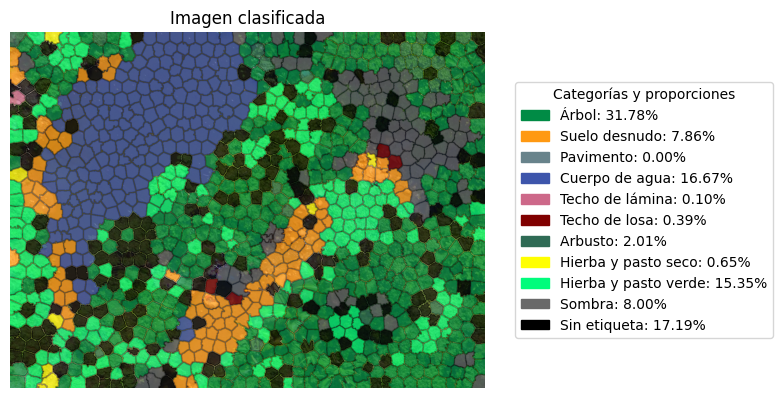

 Imagen pintada exitosamente: image_x5_1730.jpg

 Procesando y pintando imagen: image_x5_1272.jpg



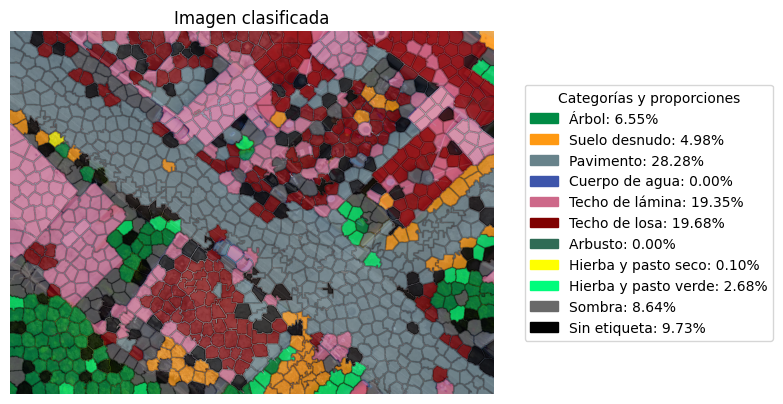

 Imagen pintada exitosamente: image_x5_1272.jpg

 Procesando y pintando imagen: image_x5_250.jpg



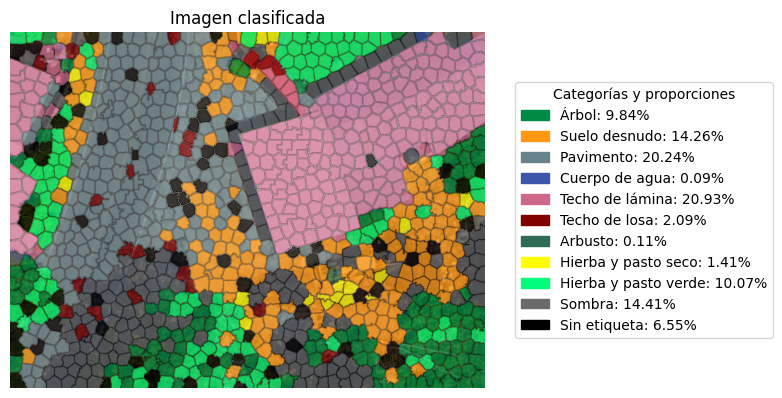

 Imagen pintada exitosamente: image_x5_250.jpg


In [46]:
from funciones_auxiliares_predicciones import img_etiquetas_parallel
import os
import pandas as pd



# Parámetros de segmentación
tamano_superpixeles = 40
ruler = 10
iteraciones = 10
tamano_minimo = 20

# Procesar cada imagen
for imagen in imagenes_jpg:
    print("\n===============================")
    print(f" Procesando y pintando imagen: {imagen}")
    print("===============================\n")
    
    try:
        # Ruta completa a la imagen
        ruta_img = os.path.join(ruta_predicciones_csv, imagen)
        
        # Segmentar imagen
        img_seg, Labels_slic, number_slic = seg_SLIC(
            path_image=ruta_img,
            parametro_1=tamano_superpixeles,
            parametro_2=ruler,
            parametro_3=iteraciones,
            parametro_4=tamano_minimo
        )
        
        # Obtener el nombre base para el CSV
        nombre_base = imagen.replace(".jpg", "")
        nombre_csv = f"Caract_paralelo_{nombre_base}_con_estrategia1.csv"
        ruta_csv = os.path.join(ruta_predicciones_csv, nombre_csv)

        # Cargar el CSV con la columna ya calculada
        df_image_pred = pd.read_csv(ruta_csv)

        # Pintar la imagen con las predicciones
        num_hilos_pintado = 10
        total_time_pintado_parallel, total_time_proporcion = img_etiquetas_parallel(
            df_image_pred["indice"],
            df_image_pred["prediction_actual_dif_estrategia1"],
            Labels_slic,
            ruta_img,
            img_seg,
            num_threads=num_hilos_pintado
        )
        print(f" Imagen pintada exitosamente: {imagen}")

    except Exception as e:
        print(f" Error procesando {imagen}: {e}")


Mostrar imagen segmentada

In [ ]:
from funciones_auxiliares_predicciones import seg_SLIC
import os
import pandas as pd
import matplotlib.pyplot as plt
import cv2



# Parámetros de segmentación
tamano_superpixeles = 40
ruler = 10
iteraciones = 10
tamano_minimo = 20

# Procesar cada imagen
for imagen in imagenes_jpg:
    print("\n===============================")
    print(f" Procesando y pintando imagen: {imagen}")
    print("===============================\n")
    
    try:
        # Ruta completa a la imagen
        ruta_img = os.path.join(ruta_predicciones_csv, imagen)

        # -------------------------------------------------
        # Mostrar imagen original
        # -------------------------------------------------
        imagen_original = cv2.imread(ruta_img)
        imagen_original = cv2.cvtColor(imagen_original, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(8, 6))
        plt.imshow(imagen_original)
        plt.title(f"Imagen original: {imagen}")
        plt.axis('off')
        plt.show()

        # Segmentar imagen
        img_seg, Labels_slic, number_slic = seg_SLIC(
            path_image=ruta_img,
            parametro_1=tamano_superpixeles,
            parametro_2=ruler,
            parametro_3=iteraciones,
            parametro_4=tamano_minimo
        )

        # -------------------------------------------------
        # Mostrar imagen segmentada (SLIC)
        # -------------------------------------------------
        plt.figure(figsize=(8, 6))
        plt.imshow(img_seg)
        plt.title(f"Segmentación SLIC: {imagen}")
        plt.axis('off')
        plt.show()
    except Exception as e:
        print(f" Error procesando {imagen}: {e}")
    
